# 16.7.1 学得预测器进入约束决策

## 学习目标与先修知识

在显式动作集合中检查预测约束、不可行与实际失配。

先修：10.6 滚动优化；15.5 混合预测；16.3 参数（parameter）估计。

## 具体问题

用学得状态（state）转移做一步约束决策。预测器认为可行时，真实系统是否必然满足约束？若无动作可行又该如何记录？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x=1.;target=1.;a_hat=.8;actions=[-.5,0.,.5];print([(u,(a_hat*x+u-target)**2+.1*u*u) for u in actions])

[(-0.5, 0.5149999999999999), (0.0, 0.03999999999999998), (0.5, 0.11500000000000002)]


## 模型假设

预测 $x^+=\hat a x+u$，实际 $x^+=a_{\rm true}x+u$；动作候选有限、$|u|\le0.5$ U、预测状态范围 [0,2] U。每次只选最小预测代价的可行动作；无可行候选返回 None，不把备用动作冒充原优化解。

## 数学解释与推导

候选目标 $J_{\rm pred}(u)=(\hat a x+u-r)^2+\rho u^2$；先检查输入（input）与预测状态约束，再在剩余动作中按成本选最小。模型误差 $\hat a-a_{\rm true}$ 使预测约束与实际约束不同。若可行集合为空，求解器失败应单独计数，并由事先声明的备用动作处理；该备用动作也必须接受实际约束检查。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def constrained_action(x,target,coefficient,actions,limit,lower,upper,penalty):
    options=[]
    for action in actions:
        if abs(action)>limit:continue
        predicted=coefficient*x+action
        if not lower<=predicted<=upper:continue
        cost=(predicted-target)**2+penalty*action*action
        options.append((cost,abs(action),action))
    return None if not options else float(min(options)[2])

## 对照实验

改变已声明的条件并比较曲线与数值。

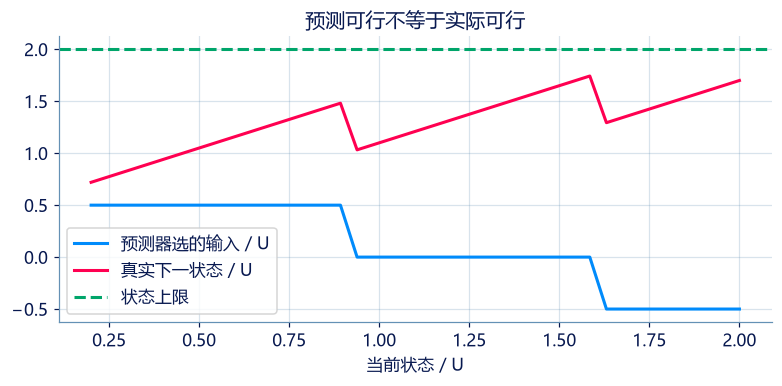

极端状态 x=4 的可行返回： None


In [4]:
actions=[-.5,0.,.5];xs=np.linspace(.2,2.,40);chosen=[];actual=[]
for x in xs:
    u=constrained_action(float(x),1.,.8,actions,.5,0.,2.,.1)
    chosen.append(np.nan if u is None else u);actual.append(np.nan if u is None else 1.1*x+u)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(xs,chosen,label="预测器选的输入 / U",color=BLUE);ax.plot(xs,actual,label="真实下一状态 / U",color=PINK);ax.axhline(2.,color=GREEN,ls="--",label="状态上限");ax.set(xlabel="当前状态 / U",title="预测可行不等于实际可行");ax.legend();ax.grid(alpha=.25);plt.show()
print("极端状态 x=4 的可行返回：",constrained_action(4.,1.,.8,actions,.5,0.,2.,.1))

## 结果解释

相同动作在 $\hat a=0.8$ 与真实系数1.1下产生不同下一状态；超界和不可行应作为失败进入评价。当前是一阶离散决策教学例，未声称一般 MPC 安全保证。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert constrained_action(4.,1.,.8,actions,.5,0.,2.,.1) is None
assert constrained_action(1.,1.,1.,actions,.5,0.,2.,.1)==0.
assert all(u is None or abs(u)<=.5 for u in chosen if not np.isnan(u))
print("可行集、零代价解与失败返回核验通过。")

可行集、零代价解与失败返回核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：预测约束与真实约束

候选在 a_hat 模型（model）下预测状态（state）位于 [0,2]，真实 a 不同，能保证实际状态仍在区间吗？

- **A.** 不能，需要实际模型误差或鲁棒裕度的证据。
- **B.** 能，只要输入（input）在限制内。
- **C.** 能，只要代价最低。
- **D.** 能，只要返回了动作。

[作答：预测约束与真实约束](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-pred-vs-actual)

### 第 2 题 · 单项选择题：无可行候选

有限动作集合里没有任何满足预测约束的动作，应如何记录？

- **A.** 把0强行写成优化最优解。
- **B.** 返回无可行解并单独说明备用动作及结果。
- **C.** 删去该场景。
- **D.** 把状态（state）上限放大后仍报告原约束。

[作答：无可行候选](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-infeasible-action)

### 第 3 题 · Python 计算题：有限动作的预测可行选择

从满足输入（input）和预测状态（state）上下界的动作里最小化平方目标误差加动作惩罚；无可行解返回 None。

**函数与代码模板**

```python
def solve(
    x: float,
    target: float,
    coefficient: float,
    actions: list[float],
    limit: float,
    lower: float,
    upper: float,
    penalty: float,
) -> float | None:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前状态。 | U |
| `target` | `float` | 下一状态目标。 | U |
| `coefficient` | `float` | 预测模型（model）的状态系数。 | 1 |
| `actions` | `list[float]` | 按题给顺序候选动作。 | U |
| `limit` | `float` | 动作绝对上限。 | U |
| `lower` | `float` | 预测状态下界。 | U |
| `upper` | `float` | 预测状态上界。 | U |
| `penalty` | `float` | 动作平方惩罚。 | 1 |

**返回值**

直接返回 action（float | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `action` | <code>float &#124; None</code> | 最优预测可行动作；没有时为 None。 | U |

**计算规则**

过滤 |action|>limit 或预测状态不在[lower,upper]的动作；在剩余动作中最小化 (预测-target)²+penalty*action²；并列时先选 |action| 小者，再选动作数值小者；无可行解返回 None。

**约束与边界**

- 候选动作非空且≤100；limit≥0、lower≤upper、penalty≥0；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前状态。 | 1 | U |
| target | 下一状态目标。 | 1 | U |
| coefficient | 预测模型（model）的状态系数。 | 1 | 1 |
| actions | 按题给顺序候选动作。 | [-1.0, 0.0, 1.0] | U |
| limit | 动作绝对上限。 | 1 | U |
| lower | 预测状态下界。 | 0 | U |
| upper | 预测状态上界。 | 2 | U |
| penalty | 动作平方惩罚。 | 0.1 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 1.0
target = 1.0
coefficient = 1.0
actions = [-1.0, 0.0, 1.0]
limit = 1.0
lower = 0.0
upper = 2.0
penalty = 0.1

result = solve(x, target, coefficient, actions, limit, lower, upper, penalty)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| action | 最优预测可行动作；没有时为 None。 | 0 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.0
```

**样例解释**

首例动作0预测状态1，代价0；第二例所有候选预测状态超过上界，应返回 None。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：有限动作的预测可行选择](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-feasible-action)

### 第 4 题 · Python 计算题：模型误差下的预测约束

按给定预测系数选择动作；本函数不读取隐藏真实系数，也不声称实际约束满足。

**函数与代码模板**

```python
def solve(
    x: float,
    target: float,
    coefficient: float,
    actions: list[float],
    limit: float,
    lower: float,
    upper: float,
    penalty: float,
) -> float | None:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前状态（state）。 | U |
| `target` | `float` | 目标状态。 | U |
| `coefficient` | `float` | 已拟合预测系数。 | 1 |
| `actions` | `list[float]` | 有限候选动作。 | U |
| `limit` | `float` | 动作上限。 | U |
| `lower` | `float` | 预测状态下界。 | U |
| `upper` | `float` | 预测状态上界。 | U |
| `penalty` | `float` | 动作惩罚。 | 1 |

**返回值**

直接返回 action（float | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `action` | <code>float &#124; None</code> | 预测可行的最低代价动作或 None。 | U |

**计算规则**

过滤 |action|>limit 或预测状态不在[lower,upper]的动作；在剩余动作中最小化 (预测-target)²+penalty*action²；并列时先选 |action| 小者，再选动作数值小者；无可行解返回 None。

**约束与边界**

- 候选动作非空且≤100；limit≥0、lower≤upper、penalty≥0；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前状态（state）。 | 1 | U |
| target | 目标状态。 | 1.5 | U |
| coefficient | 已拟合预测系数。 | 1 | 1 |
| actions | 有限候选动作。 | [0.0, 0.5, 1.0] | U |
| limit | 动作上限。 | 1 | U |
| lower | 预测状态下界。 | 0 | U |
| upper | 预测状态上界。 | 1.5 | U |
| penalty | 动作惩罚。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 1.0
target = 1.5
coefficient = 1.0
actions = [0.0, 0.5, 1.0]
limit = 1.0
lower = 0.0
upper = 1.5
penalty = 0.0

result = solve(x, target, coefficient, actions, limit, lower, upper, penalty)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| action | 预测可行的最低代价动作或 None。 | 0.5 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.5
```

**样例解释**

首例动作0.5 恰好达到预测上界且目标误差为0；不等于真实模型（model）必满足约束。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：模型误差下的预测约束](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-prediction-feasible)

**进一步阅读**

[Boyd 的凸优化教材](https://web.stanford.edu/~boyd/cvxbook/)给出约束优化基础；此处动作枚举不等于一般 MPC 求解器。